In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / 'src'))

# Análise de Data Science: Sistema de Recomendação Nintendo Switch

Este notebook complementa a solução com a componente analítica: **avaliação dos métodos
de recomendação** e a **quantificação do viés de popularidade**.

## 1. Os três métodos de recomendação

O sistema oferece três sinais, que respondem a perguntas diferentes:

- **Co-ocorrência bruta**: quantas vezes dois produtos foram comprados juntos (contagem absoluta).
- **Cosseno**: semelhança de *perfil* de co-compra entre produtos.
- **NPMI**: mede a força de associação entre dois itens, eliminando o efeito da popularidade individual (Market Basket Analysis).

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from evaluation import ranking_agreement, topn_overlap, popularity_bias


Matplotlib is building the font cache; this may take a moment.


## 2. Concordância entre métodos

Se dois métodos produzem o mesmo ranking, são redundantes. Se divergem, cada um traz informação nova. Mediu-se com correlação de Spearman (ordem das recomendações) e sobreposição do top-N (o que o utilizador vê).

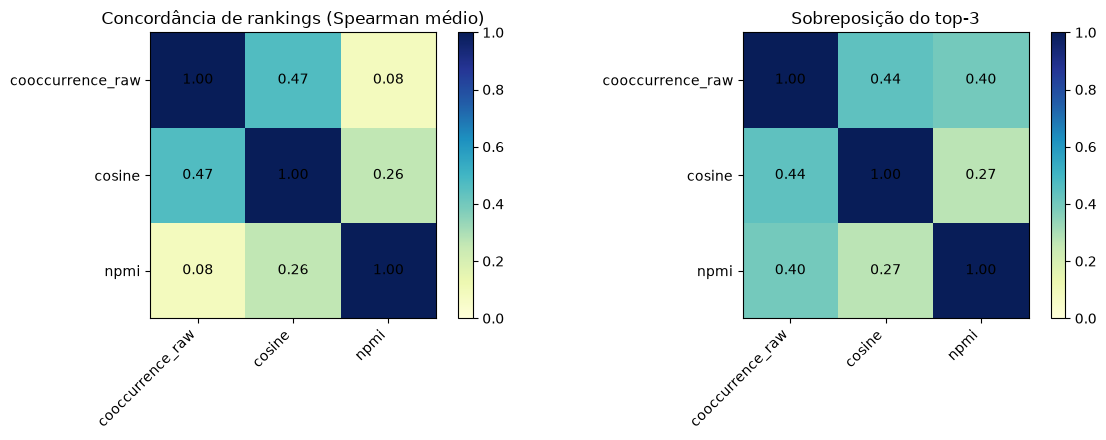

                  cooccurrence_raw  cosine   npmi
cooccurrence_raw             1.000   0.467  0.084
cosine                       0.467   1.000  0.261
npmi                         0.084   0.261  1.000


In [3]:
agreement = ranking_agreement()
overlap = topn_overlap(top_n=3)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, data, title in [
    (axes[0], agreement, "Concordância de rankings (Spearman médio)"),
    (axes[1], overlap, "Sobreposição do top-3"),
]:
    im = ax.imshow(data.values, cmap="YlGnBu", vmin=0, vmax=1)
    ax.set_xticks(range(len(data.columns))); ax.set_xticklabels(data.columns, rotation=45, ha="right")
    ax.set_yticks(range(len(data.index))); ax.set_yticklabels(data.index)
    for i in range(len(data.index)):
        for j in range(len(data.columns)):
            ax.text(j, i, f"{data.values[i,j]:.2f}", ha="center", va="center")
    ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()

print(agreement)


**Interpretação:** Co-ocorrência bruta e cosseno concordam moderadamente. O **NPMI diverge claramente** dos outros dois: capta a associação real entre itens, não apenas co-ocorrência frequente. Isto confirma que o NPMI **não é redundante** (acrescenta uma
perspetiva, em vez de repetir a co-ocorrência).

## 3. Viés de popularidade

A co-ocorrência bruta tem um problema conhecido: produtos muito vendidos co-ocorrem com tudo, só por serem populares. Medimos isso correlacionando o score que cada produto recebe como recomendação com a sua popularidade (`times_sold`). **Correlação alta = viés.**

          method  corr_com_popularidade  p_value
cooccurrence_raw                  0.849    0.000
          cosine                 -0.038    0.888
            npmi                 -0.340    0.197


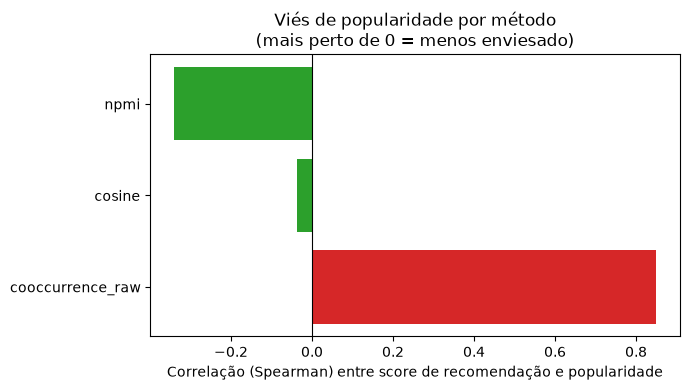

In [ ]:
bias = popularity_bias()
print(bias.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
colors = ["#d62728" if v > 0.5 else "#2ca02c" for v in bias["corr_com_popularidade"]]
ax.barh(bias["method"], bias["corr_com_popularidade"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Correlação (Spearman) entre score de recomendação e popularidade")
ax.set_title("Viés de popularidade por método\n(mais perto de 0 = menos enviesado)")
plt.tight_layout(); plt.show()


**Interpretação:**

A co-ocorrência bruta mostra correlação **muito forte** com a popularidade: na prática, recomenda
best-sellers independentemente da afinidade real. O **cosseno** neutraliza quase totalmente esse viés,
e o **NPMI** chega a penalizar ligeiramente os produtos populares (exatamente o comportamento desejado
de uma métrica de associação).

Ou seja: a escolha do NPMI como motor principal, é uma resposta quantificada a um problema. Esta é a justificação que sustenta toda a arquitetura de recomendação.

*Nota:* o p-value do NPMI não é significativo (amostra pequena), por isso falamos de
**tendência**, não de significância estatística. Com mais produtos, esperaríamos a mesma tendência com intervalos mais apertados.